In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import sbibm

from pyro_cases.run import train_and_test

In [3]:
device = torch.device("cuda:2")

In [4]:
sbibm.get_available_tasks()

['sir',
 'two_moons',
 'slcp',
 'gaussian_linear_uniform',
 'lotka_volterra',
 'bernoulli_glm',
 'gaussian_mixture',
 'gaussian_linear',
 'slcp_distractors',
 'bernoulli_glm_raw']

In [5]:
# torch.autograd.set_detect_anomaly(True)

In [6]:
out_dict = train_and_test(task_name="arm_electric_1b",
                          seed=12345,
                          device=device,
                          lr=1e-3,
                          lr_schedule="custom_decrease",
                          num_particles=1,
                          vectorize_particles=False,
                          batch_size=1024,
                          network_width=1024,
                          steps=10_000,
                          show_progress=True)

100%|██████████| 10000/10000 [04:02<00:00, 41.22it/s]


[12345 completes] task start time: Sat Mar 22 21:15:23 2025; task end time: Sat Mar 22 21:19:25 2025; cost time: 242.7 seconds


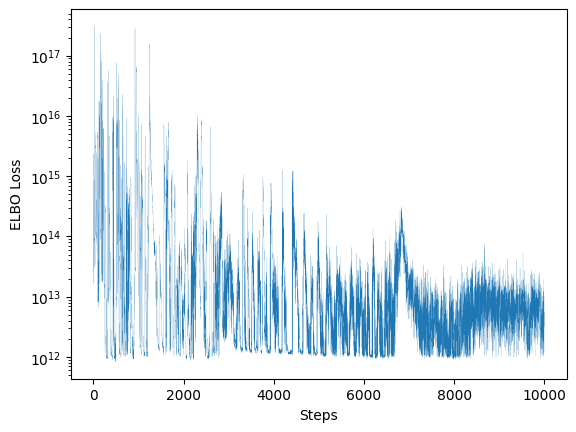

In [7]:
plt.plot(out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.yscale("log")
plt.show()

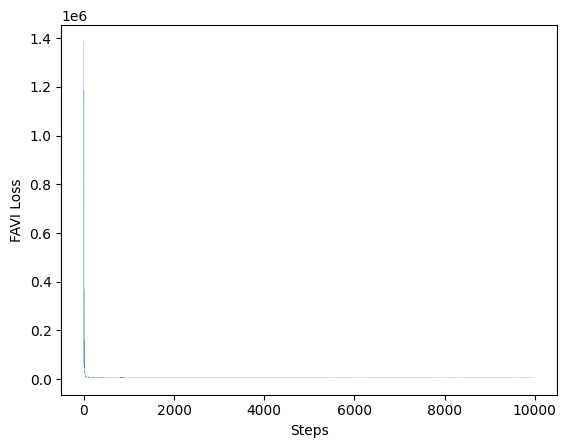

In [8]:
plt.plot(out_dict["favi_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("FAVI Loss")
# plt.yscale("log")
plt.show()

In [9]:
out_dict["elbo_test_dict_list"][0]["obs_seed"]

10000

In [10]:
out_dict["elbo_test_dict_list"][0]["obs"]

tensor([[7.0000e+00, 7.0000e+00, 0.0000e+00, 8.0000e+00, 4.0000e+00, 8.0000e+00,
         3.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00, 0.0000e+00, 6.0000e+00,
         7.0000e+00, 4.0000e+00, 4.0000e+00, 1.0000e+00, 1.0000e+00, 5.0000e+00,
         0.0000e+00, 2.0000e+00, 9.0000e+00, 5.0000e+00, 3.0000e+00, 1.0000e+00,
         4.0000e+00, 0.0000e+00, 5.0000e+00, 5.0000e+00, 9.0000e+00, 1.0000e+00,
         7.0000e+00, 6.0000e+00, 2.0000e+00, 8.0000e+00, 2.0000e+00, 0.0000e+00,
         1.0000e+00, 6.0000e+00, 1.0000e+00, 6.0000e+00, 0.0000e+00, 4.0000e+00,
         4.0000e+00, 1.0000e+00, 7.0000e+00, 8.0000e+00, 6.0000e+00, 6.0000e+00,
         6.0000e+00, 7.0000e+00, 3.2000e+01, 3.8000e+01, 2.2000e+01, 3.8000e+01,
         2.3000e+01, 3.4000e+01, 3.1000e+01, 3.7000e+01, 2.7000e+01, 3.3000e+01,
         3.8000e+01, 2.1000e+01, 2.6000e+01, 3.9000e+01, 3.0000e+01, 2.4000e+01,
         2.2000e+01, 2.2000e+01, 3.8000e+01, 2.7000e+01, 3.2000e+01, 2.1000e+01,
         2.5000e+01, 3.4000e

In [11]:
out_dict["elbo_test_dict_list"][0]["true_theta"]

tensor([  0.9904,  92.0410,  82.1547, 102.9779, 105.5633, 101.0689,  33.7718,
        139.0940])

In [12]:
out_dict["elbo_test_dict_list"][0]["est_mu"]

tensor([ 2.2637e-02,  4.1391e+03,  3.9769e+03,  3.8405e+03,  4.8371e+03,
         4.6807e+03,  5.9006e+01, -1.3954e-01])

In [13]:
out_dict["elbo_test_dict_list"][0]["est_sigma2"]

tensor([5.0000e-04, 5.0000e+00, 5.0000e+00, 5.0000e+00, 5.0000e+00, 5.0000e+00,
        5.0000e+00, 5.0000e-04])

In [14]:
out_dict["favi_test_dict_list"][0]["obs_seed"]

10000

In [15]:
out_dict["favi_test_dict_list"][0]["obs"]

tensor([[7.0000e+00, 7.0000e+00, 0.0000e+00, 8.0000e+00, 4.0000e+00, 8.0000e+00,
         3.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00, 0.0000e+00, 6.0000e+00,
         7.0000e+00, 4.0000e+00, 4.0000e+00, 1.0000e+00, 1.0000e+00, 5.0000e+00,
         0.0000e+00, 2.0000e+00, 9.0000e+00, 5.0000e+00, 3.0000e+00, 1.0000e+00,
         4.0000e+00, 0.0000e+00, 5.0000e+00, 5.0000e+00, 9.0000e+00, 1.0000e+00,
         7.0000e+00, 6.0000e+00, 2.0000e+00, 8.0000e+00, 2.0000e+00, 0.0000e+00,
         1.0000e+00, 6.0000e+00, 1.0000e+00, 6.0000e+00, 0.0000e+00, 4.0000e+00,
         4.0000e+00, 1.0000e+00, 7.0000e+00, 8.0000e+00, 6.0000e+00, 6.0000e+00,
         6.0000e+00, 7.0000e+00, 3.2000e+01, 3.8000e+01, 2.2000e+01, 3.8000e+01,
         2.3000e+01, 3.4000e+01, 3.1000e+01, 3.7000e+01, 2.7000e+01, 3.3000e+01,
         3.8000e+01, 2.1000e+01, 2.6000e+01, 3.9000e+01, 3.0000e+01, 2.4000e+01,
         2.2000e+01, 2.2000e+01, 3.8000e+01, 2.7000e+01, 3.2000e+01, 2.1000e+01,
         2.5000e+01, 3.4000e

In [16]:
out_dict["favi_test_dict_list"][0]["true_theta"]

tensor([  0.9904,  92.0410,  82.1547, 102.9779, 105.5633, 101.0689,  33.7718,
        139.0940])

In [17]:
out_dict["favi_test_dict_list"][0]["est_mu"]

tensor([  0.3396,   0.7110,  24.1265,  13.1660,  23.0103,  26.3368,  -7.0672,
        153.0515])

In [18]:
out_dict["favi_test_dict_list"][0]["est_sigma2"]

tensor([5., 5., 5., 5., 5., 5., 5., 5.])